## Model Selection

Before we move on we would like to choose the best possible model for each of the two cases: daily forecast and hourly forecast. It seems that for the daily forecast in the long term you choose linear_order2 in the short to medium term potentially hybrid_order2. For the hourly forecast it seems that just using XGBoost is the best possible model.

The main question is that in the daily forecast if we were to optimise the hyperparameters of the XGBoost model within the hybrid model would it make hybrid_order2 better than linear_order2 in both the short and long term. It would also be nice to do hyperparamter optimisation for the hourly forecast as well just to see whether we can improve the predictions or not. 

Finally it would be good to look at SHAP values to see if we can drop any of the features, particualarly some of the lags as they can make the models computationally expensive.

For our own use (maybe delete later): http://kaggle.com/code/prashant111/a-guide-on-xgboost-hyperparameters-tuning

https://hyperopt.github.io/hyperopt/?source=post_page

https://github.com/hyperopt/hyperopt/wiki/FMin

In [1]:
from hyperopt import hp, fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope
import xgboost as xgb
import pickle
import pandas as pd
from jfk_taxis import load_design, load_models, load_lags, run_forecasts, preprocess, forecast, create_val_data, wrapped_objective, save_hyperparams, load_hyperparams, save_obj, load_obj
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import time
import numpy as np
import cupy as cp

In [ ]:
# First reload the significant lags
daily_lags = load_lags("daily", "eda")

hourly_lags = load_lags("hourly", "eda")

used_hourly_lags = hourly_lags[:168]

In [3]:
# Get both the full daily and hourly time series
dir_path = "../data/processed/"
df_daily = pd.read_csv(f"{dir_path}ts_daily2011-2025.csv")
df_hourly = pd.read_csv(f"{dir_path}ts_hour2011-2025.csv")

# Convert dates to datetime objects
df_daily["pickup_date"] = pd.to_datetime(df_daily["pickup_date"])
df_hourly["dt"] = pd.to_datetime(df_hourly["dt"])


In [4]:
# To pass the time series through our helper functions they need to be a pandas series indexed by a datetime object:
ts_hourly = df_hourly["trips"]
ts_hourly.index = df_hourly["dt"]

ts_daily = df_daily["trips"]
ts_daily.index = df_daily["pickup_date"]

In [5]:
# We now need to split into test and train data, we will train on the pre 2024 data and test on 2024 onwards, approx a 90:10 split
ts_daily_train = ts_daily[:"2023-12-31"]
ts_daily_test = ts_daily["2024-01-01":]

ts_hourly_train = ts_hourly[:"2023-12-31"]
ts_hourly_test = ts_hourly["2024-01-01":]

In [6]:
# Define search space
space = {
    # We rely on early stopping when fitting so this isn't an optimised value
    # number of trees
    "n_estimators": 500,

    # Learning rate
    # step size shrinkage, smaller = slower but more precise learning
    "learning_rate": 0.05,

    # Depth/complexity
    # Max depth of tree, larger more complex trees but can cause overfitting
    "max_depth": scope.int(hp.quniform("max_depth", 3, 6, 1)), # scope.int ensures we take ints only
    # minimum "weight" needed in child node. Higher values more conservative, fewer splits helps prevent overfitting
    "min_child_weight": hp.loguniform("min_child_weight", -2.3, 2.3), # approx [0.1, 10]

    # Randomisation/feature subsampling
    # fraction of rows used per tree, lower adds randomness reduces overfitting
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    # fraction of features used per tree
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),

    # Regularisation
    # L2 penalty, good range is [0.1, 10] we use loguniform because this means that every order of magnitude has equal probability, the def of log uniform in hyperopt is that it returns a value exp(U(low,high)) where U is uniform dist.  
    "reg_lambda": hp.loguniform("reg_lambda", np.log(1e-2), np.log(100)), # [0.01, 100]
    # L1 penalty
    "reg_alpha": hp.loguniform("reg_alpha", np.log(1e-3), np.log(10)), # [0.001, 10]

    # Split pnealty (gamma) 
    # minimum loss reduction required to split a node, higher values = more conservative
    "gamma": hp.loguniform("gamma", -7.0, 2.3), # approx [0.0009, 10]

    "random_state": 37,
    #"early_stopping_rounds": 100,
    "eval_metric": "mae", 
    "tree_method": "hist",
    "device": "cuda" # Use GPU if available
}
    
    

There are a few interesting things we would like to vary when doing our Bayesian hyperparamter optimisation. The first is that we want to both include and exclude COVID from the data we use to tune hyperparamters on.

The reason for this is because during COVID the usual seasonality breaks down dramatically as we get unusal travel patterns. So it may be worth tuning a model on data without COVID as then it is being asseseed more on its ability to pick up the more "normal" patterns within the data. You then have a question of do you use pre or post COVID data, there is more pre COVID data but it will obviously be less relevant for forecasting in the present. Alternatively it may be actually be worth including the COVID data as then the model is tuned to be more robust to "unusal" regimines within the data.

So as it's not clear which of the three will be optimal we will just run all three and then compare the models that hyperopt finds.

For the daily series we wil use a 30 day forecast in our objection function to validate with. For the hourly series we will do a weekly forecast (168 hours).

In [7]:
# Dictionary of parameters for Baysian optimisation
bayes_dict = {}

In [8]:
# Daily non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = 5
test_size = 30
lags = daily_lags
constant = False
order = 0
fourier_features = ["YE", "W"]
time_step = "D"
hybrid = None
steps = 30


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_non_linear_incl_COVID": ts_daily_train,
    "daily_non_linear_post_COVID": ts_daily_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }

In [9]:
# Daily non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = 5
test_size = 30
lags = daily_lags
constant = True
order = 2 # we use 2nd order as this performed the best in the purely linear case, the hybrid model is just a boosted version of the purely linear case so we expect order 2 to perform the best
fourier_features = ["YE", "W"]
time_step = "D"
hybrid = LinearRegression(fit_intercept= False)
steps = 30


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "daily_hybrid_non_linear_pre_COVID": ts_daily_train[:"2020-01-01"],
    "daily_hybrid_non_linear_incl_COVID": ts_daily_train,
    "daily_hybrid_non_linear_post_COVID": ts_daily_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }

In [10]:
# Hourly non_linear pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = 5
test_size = 168
lags = hourly_lags
constant = False
order = 0
fourier_features = ["D", "W"]
time_step = "h"
hybrid = None
steps = 168


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_non_linear_incl_COVID": ts_hourly_train,
    "hourly_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }


In [11]:
# Hourly non_linear hybrid pre, incl and post COVID

# Set the parameters for creat_val_data and the objective function
n_splits = 5
test_size = 168
lags = hourly_lags
constant = True
order = 2 # we use 2nd order as this performed the best in the purely linear case, the hybrid model is just a boosted version of the purely linear case so we expect order 2 to perform the best
fourier_features = ["D", "W"]
time_step = "h"
hybrid = LinearRegression(fit_intercept= False)
steps = 168


# Looping through this dict avoids having to have three separate code cells, the keys are the sigs, values are the tsk
tmp_dict = {
    "hourly_hybrid_non_linear_pre_COVID": ts_hourly_train[:"2020-01-01"],
    "hourly_hybrid_non_linear_incl_COVID": ts_hourly_train,
    "hourly_hybrid_non_linear_post_COVID": ts_hourly_train["2022-01-01":]
}

# Add to Bayes dict
for key, value in tmp_dict.items():
    bayes_dict[key] = {
        "n_splits" : n_splits,
        "test_size" : test_size,
        "lags" : lags,
        "constant" : constant,
        "order" : order,
        "fourier_features" : fourier_features,
        "time_step" : time_step,
        "ts" : value,
        "hybrid" : hybrid,
        "steps" : steps
    }


In [ ]:
# Loop through the Bayes dict, create the folds and run fmin for 100 evals to optimise hyperparamters, save the hyperparameters and sigs to a .pkl object

# list to store the keys
sig_list = []

for key, value in bayes_dict.items():
    print(f"Running hyperparameter optimisation for {key}")
    
    # Create the folds
    fold_dict = create_val_data(value["n_splits"], value["test_size"], value["lags"], value["constant"], value["order"], value["fourier_features"], value["time_step"], value["ts"])

    # Set attributes of wrapped_objective
    wrapped_objective.fold_dict = fold_dict
    wrapped_objective.lags = value["lags"]
    wrapped_objective.steps = value["steps"]
    wrapped_objective.hybrid = value["hybrid"]

    # Optimisation algorithm
    trials = Trials()

    best_hyperparams = fmin(fn = wrapped_objective,
                            space = space,
                            algo = tpe.suggest,
                            max_evals = 100,
                            trials = trials)

    # Log hyperparams 
    print("The best hyperparamters are: ", "\n")
    print(best_hyperparams)

    # Save hyperparams
    save_hyperparams(best_hyperparams, key)

# Save signatures
save_obj(sig_list, "hyperparam_sigs")

Running hyperparameter optimisation for daily_non_linear_pre_COVID
Fold 0
[   0    1    2 ... 3135 3136 3137]
Fold 1
[   0    1    2 ... 3165 3166 3167]
Fold 2
[   0    1    2 ... 3195 3196 3197]
Fold 3
[   0    1    2 ... 3225 3226 3227]
Fold 4
[   0    1    2 ... 3255 3256 3257]
(2767, 360)                                            
  0%|          | 0/100 [00:00<?, ?trial/s, best loss=?]

c:\Users\ogilv\miniconda3\envs\datasci\Lib\site-packages\xgboost\core.py:705: UserWarning: [16:52:06] WARNING: D:\bld\xgboost-split_1755048447205\work\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Fit time: 8.23 seconds                                 
Predict time: 0.3217 seconds                           
(2797, 360)                                            
Fit time: 8.26 seconds                                 
Predict time: 0.3116 seconds                           
(2827, 360)                                            
Fit time: 8.23 seconds                                 
Predict time: 0.3127 seconds                           
(2857, 360)                                            
Fit time: 8.28 seconds                                 
Predict time: 0.3099 seconds                           
(2887, 360)                                            
Fit time: 8.15 seconds                                 
Predict time: 0.3067 seconds                           
MAEs:                                                  
[401.3205240885417, 419.491943359375, 388.41749674479166, 892.538427734375, 819.2361328125]
Avg MAE:                                               
584.20090494

In [ ]:
# Load hyperparameters
sig = "daily_non_linear"

best_hyperparams = load_hyperparams(sig)

In [ ]:
# Load signatures
hyper_sig = load_obj("hyperparam_sigs")

# Dict of hyperparams
hyper_dict = {}

# Load the hyperparams for each model
for sig in hyper_sig:
    hyper_params = load_hyperparams(sig)
    hyper_dict[sig] = hyper_params


In [ ]:
# The first interesting thing to compare would be how do the models tuned on pre, incl and post COVID compare to each other as well as to the previous best model from the modelling notebook
# to make this easier we will split up into four dicts, daily non-linear, daily hybrid, hourly non-linear, hourly hybrid

daily_non_linear_dict = {}
daily_hybrid_dict = {}
hourly_non_linear_dict = {}
hourly_hybrid_dict = {}

# Split into the four dicts
for key, value in hyper_dict.items():
    if "daily" and "hybrid" in key:
        daily_hybrid_dict[key] = value
    elif "daily" in key:
        daily_non_linear_dict[key] = value
    elif "hourly" and "hybrid" in key:
        hourly_hybrid_dict[key] = value
    elif "hourly" in key:
        hourly_non_linear_dict[key] = value

# Create dict of these dicts just to make looping easier
dict_full = {
    "daily": daily_non_linear_dict, 
    "daily_hybrid": daily_hybrid_dict, 
    "hourly": hourly_non_linear_dict, 
    "hourly_hybrid": hourly_hybrid_dict
    }

In [ ]:
# Loop through each dict, load the relevant design and target matricies, fit the models and then forecast on the test set
for key, value in dict_full.items():
    if key == "daily":
        # Load the previous non linear model
        linear_models_loaded, non_linear_models_loaded = load_models("5_order_linear_daily")

        # Load the previous non linear design matrix
        linear_design_loaded, non_linear_design_loaded = load_design("5_order_linear_daily")

        # Get design, target and dp
        X = non_linear_design_loaded["base_non_linear"][0]
        y = non_linear_design_loaded["base_non_linear"][1]
        dp = non_linear_design_loaded["base_non_linear"][2]

        # Define the model, **value will pass the dict of hyperparamters to the XGBRegressor 
        new_non_linear = xgb.XGBRegressor(
            **value,
            eval_metric="mae",
            n_estimators=500,
            device = "cuda"
        )

        # Fit the model
        new_non_linear.fit(X,y)

        # Add this non linear model to the dict of non linear models
        non_linear_models_loaded["new_non_linear"] = new_non_linear
        
        # We will only include linear_order_2 in this plot
        linear_order_2 = linear_models_loaded["linear_order_2"]
        linear_models_loaded = {"linear_order_2": linear_order_2}

        # Steps for the forecast
        steps = [1, 2, 3, 7, 14, 28, 30, 60, 180, 365, 500, 546]

        # Run forecasts
        run_forecasts(steps, daily_lags, linear_models_loaded, non_linear_models_loaded, True, "D", ts_daily_train, ts_daily_test)
    
    elif key == "daily_hybrid":
        # Load the previous non linear model
        hybrid_models_loaded, non_linear_models_loaded = load_models("2_order_hybrid_daily")

        # Load the previous non linear design matrix
        hybrid_design_loaded, non_linear_design_loaded = load_design("2_order_hybrid_daily")

        # Define the model, **value will pass the dict of hyperparamters to the XGBRegressor 
        new_hybrid = xgb.XGBRegressor(
            **value,
            eval_metric="mae",
            n_estimators=500,
            device = "cuda"
        )

        # The difference for hybrid models is that our newly defined model is actually the hybrid component not the model component
        # The design and target matricies for hybrid_order_1 and hybrid_order_2 are the same
        X = hybrid_design_loaded["hybrid_order_1"][0]
        y = hybrid_design_loaded["hybrid_order_1"][1]
        dp = hybrid_design_loaded["hybrid_order_1"][2]

        # We will need to fit new_hybrid to the residuals of the model
        for i in [1,2]:
            # Compute residuals
            y_fit = hybrid_models_loaded[f"hybrid_order_{i}"][0].predict(X)
            y_resid = y - y_fit

            # Fit hybrid to residuals
            new_hybrid.fit(X, y_resid)

            # Add this hybrid model to the dict of hybrid models
            hybrid_models_loaded[f"new_hybrid_order_{i}"] = (hybrid_models_loaded[f"hybrid_order_{i}"][0], hybrid_models_loaded[f"hybrid_order_{i}"][1], new_hybrid) 
    
        # Steps for the forecast
        steps = [1, 2, 3, 7, 14, 28, 30, 60, 180, 365, 500, 546]

        # Run forecasts
        run_forecasts(steps, daily_lags, linear_models_loaded, non_linear_models_loaded, True, "D", ts_daily_train, ts_daily_test)

    elif key == "hourly":
        # Load the previous non linear model
        linear_models_loaded, non_linear_models_loaded = load_models("5_order_linear_hourly")

        # Load the previous non linear design matrix
        linear_design_loaded, non_linear_design_loaded = load_design("5_order_linear_hourly")

        # Get design, target and dp
        X = non_linear_design_loaded["base_non_linear"][0]
        y = non_linear_design_loaded["base_non_linear"][1]
        dp = non_linear_design_loaded["base_non_linear"][2]

        # Define the model, **value will pass the dict of hyperparamters to the XGBRegressor
        new_non_linear = xgb.XGBRegressor(
            **value,
            eval_metric="mae",
            n_estimators=500,
            device = "cuda"
        )

        # Fit the model
        new_non_linear.fit(X,y)

        # Add this non linear model to the dict of non linear models
        non_linear_models_loaded["new_non_linear"] = new_non_linear

        # We will only include linear_order_2 in this plot
        linear_order_2 = linear_models_loaded["linear_order_2"]
        linear_models_loaded = {"linear_order_2": linear_order_2}

        # Steps for the forecast
        steps = [1, 4, 6, 12, 24, 48, 72, 96, 120, 168, 336, 720]

        # Run forecasts
        run_forecasts(steps, used_hourly_lags, linear_models_loaded, non_linear_models_loaded, True, "h", ts_hourly_train, ts_hourly_test)
    
    elif key == "hourly_hybrid":
        # Load the previous non linear model
        hybrid_models_loaded, non_linear_models_loaded = load_models("2_order_hybrid_hourly")

        # Load the previous non linear design matrix
        hybrid_design_loaded, non_linear_design_loaded = load_design("2_order_hybrid_hourly")

        # Define the model, **value will pass the dict of hyperparamters to the XGBRegressor 
        new_hybrid = xgb.XGBRegressor(
            **value,
            eval_metric="mae",
            n_estimators=500,
            device = "cuda"
        )

        # The difference for hybrid models is that our newly defined model is actually the hybrid component not the model component
        # The design and target matricies for hybrid_order_1 and hybrid_order_2 are the same
        X = hybrid_design_loaded["hybrid_order_1"][0]
        y = hybrid_design_loaded["hybrid_order_1"][1]
        dp = hybrid_design_loaded["hybrid_order_1"][2]

        # We will need to fit new_hybrid to the residuals of the model
        for i in [1,2]:
            # Compute residuals
            y_fit = hybrid_models_loaded[f"hybrid_order_{i}"][0].predict(X)
            y_resid = y - y_fit

            # Fit hybrid to residuals
            new_hybrid.fit(X, y_resid)

            # Add this hybrid model to the dict of hybrid models
            hybrid_models_loaded[f"new_hybrid_order_{i}"] = (hybrid_models_loaded[f"hybrid_order_{i}"][0], hybrid_models_loaded[f"hybrid_order_{i}"][1], new_hybrid) 
 
        # Steps for the forecast
        steps = [1, 4, 6, 12, 24, 48, 72, 96, 120, 168, 336, 720]   

        # Run forecasts
        run_forecasts(steps, used_hourly_lags, linear_models_loaded, non_linear_models_loaded, True, "h", ts_daily_train, ts_daily_test)


In [ ]:
# It would now be interesting to use this hyperparams and use them on the forecasts from the previous notebook to see how they compare

# Load the previous non linear model
linear_models_loaded, non_linear_models_loaded = load_models("5_order_linear_daily")

# Load the previous non linear design matrix
linear_design_loaded, non_linear_design_loaded = load_design("5_order_linear_daily")

# Get design, target and dp
X = non_linear_design_loaded["base_non_linear"][0]
y = non_linear_design_loaded["base_non_linear"][1]
dp = non_linear_design_loaded["base_non_linear"][2]

# Now create our new non linear model trained on the full training data set
new_non_linear = xgb.XGBRegressor(
        n_estimators = space["n_estimators"],
        learning_rate = space["learning_rate"],
        max_depth = int(best_hyperparams["max_depth"]),
        min_child_weight = best_hyperparams["min_child_weight"],
        subsample = best_hyperparams["subsample"],
        colsample_bytree = best_hyperparams["colsample_bytree"],
        gamma = best_hyperparams["gamma"],
        reg_alpha = best_hyperparams["reg_alpha"],
        reg_lambda = best_hyperparams["reg_lambda"],
        random_state = 37,
        eval_metric = "mae",
        tree_method = "hist",
        device = "cuda"
        )


new_non_linear.fit(X, y,
    verbose = False)

non_linear_models_loaded["new_non_linear"] = (new_non_linear, dp, None)

In [ ]:
# Steps for the forecast
steps = [1, 2, 3, 7, 14, 28, 30, 60, 180, 365, 500, 546]


MAE Non Linear: 230.66 for step = 1, model = base_non_linear
MAE Non Linear: 286.90 for step = 1, model = new_non_linear


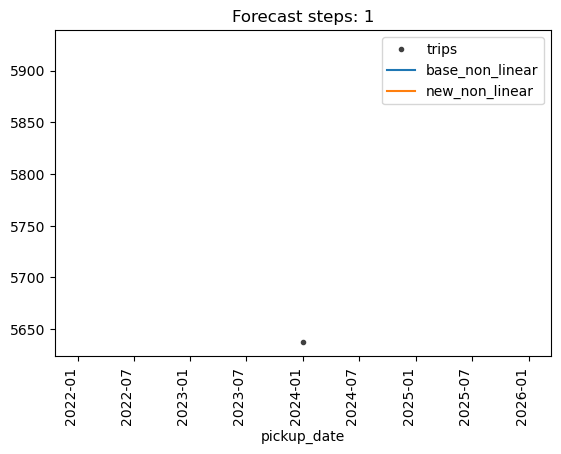

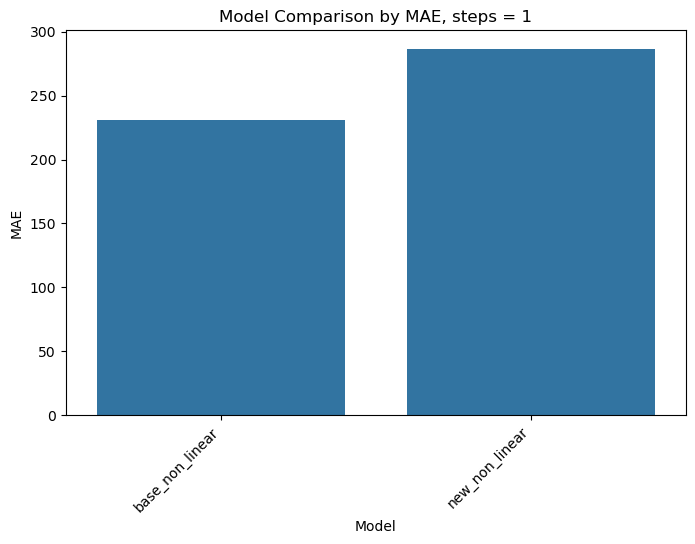

MAE Non Linear: 473.48 for step = 2, model = base_non_linear
MAE Non Linear: 562.86 for step = 2, model = new_non_linear


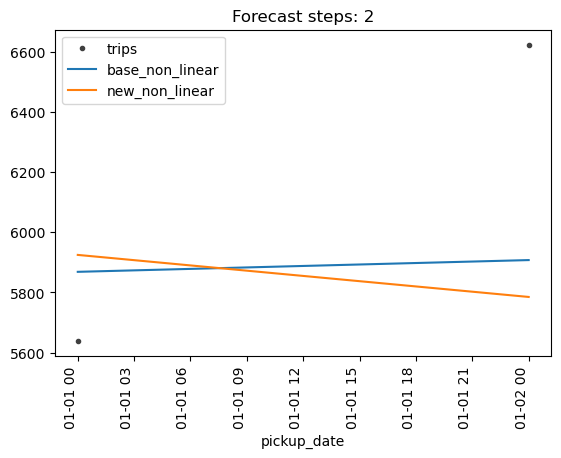

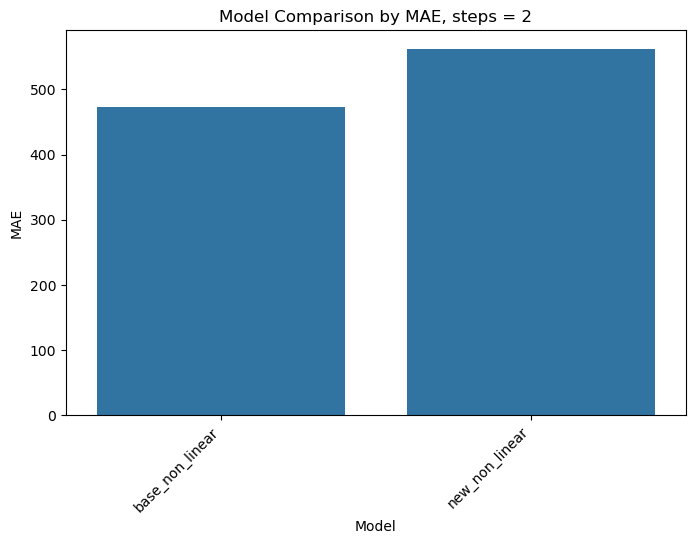

MAE Non Linear: 447.01 for step = 3, model = base_non_linear
MAE Non Linear: 467.61 for step = 3, model = new_non_linear


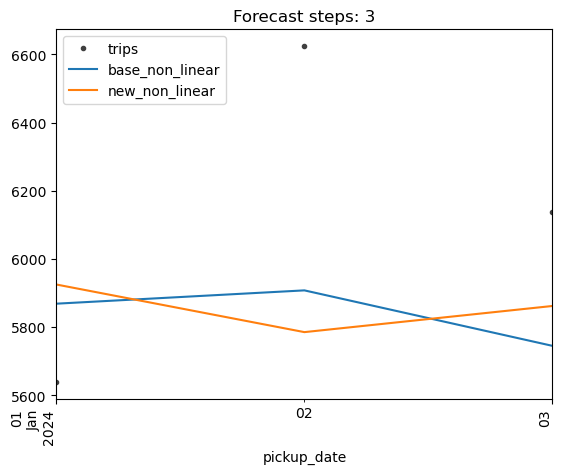

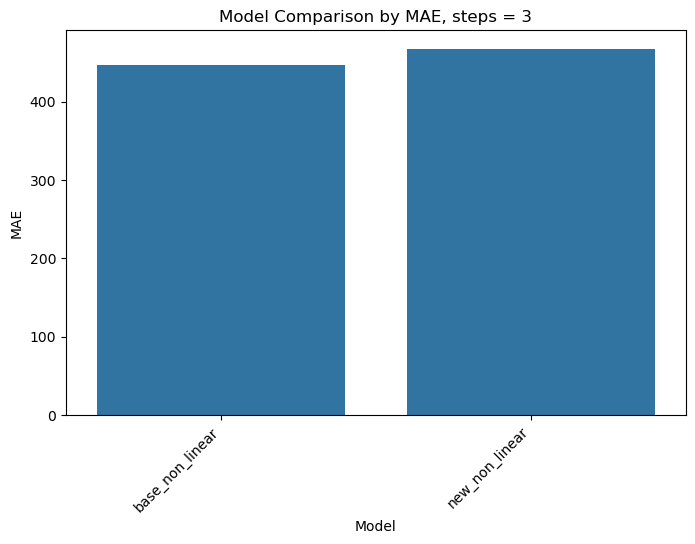

MAE Non Linear: 470.55 for step = 7, model = base_non_linear
MAE Non Linear: 505.84 for step = 7, model = new_non_linear


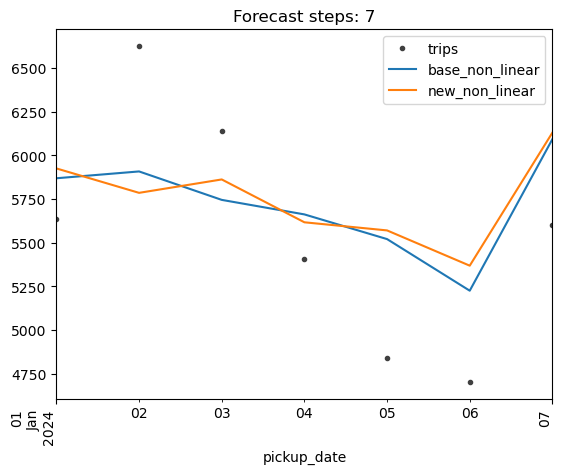

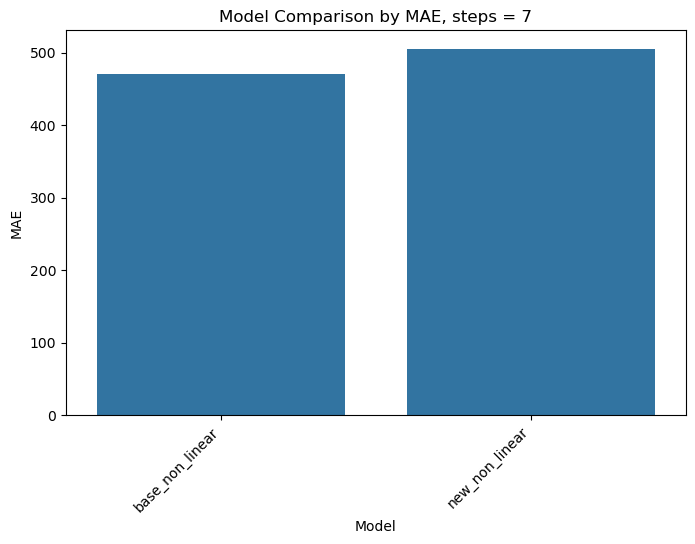

MAE Non Linear: 529.12 for step = 14, model = base_non_linear
MAE Non Linear: 531.99 for step = 14, model = new_non_linear


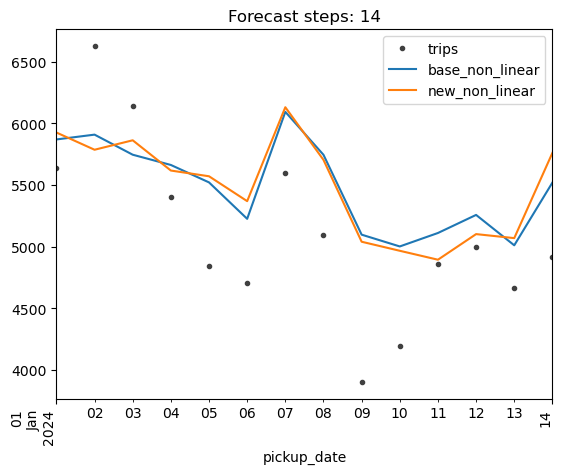

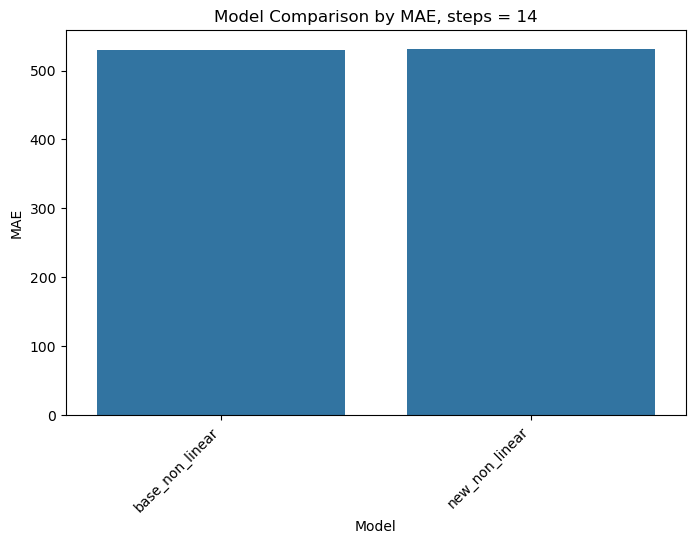

MAE Non Linear: 587.55 for step = 28, model = base_non_linear
MAE Non Linear: 614.63 for step = 28, model = new_non_linear


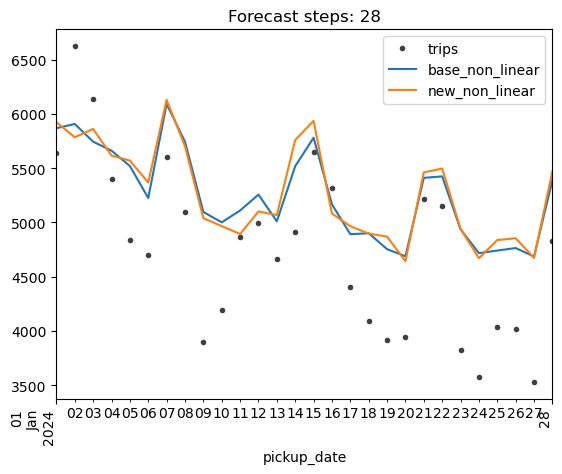

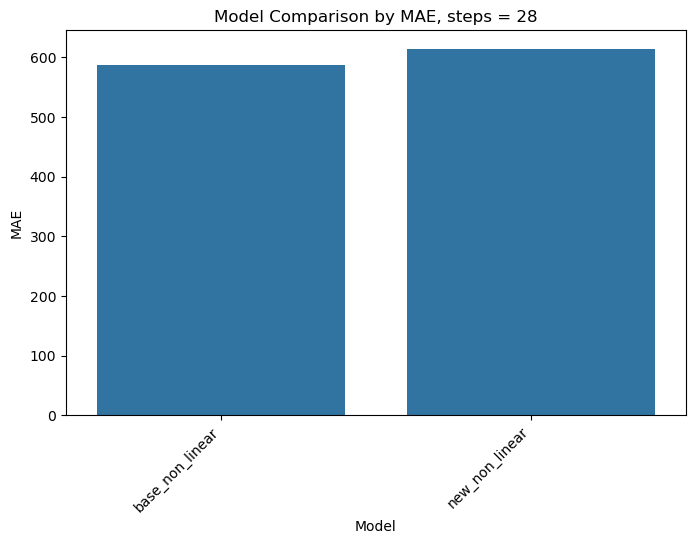

MAE Non Linear: 603.34 for step = 30, model = base_non_linear
MAE Non Linear: 632.88 for step = 30, model = new_non_linear


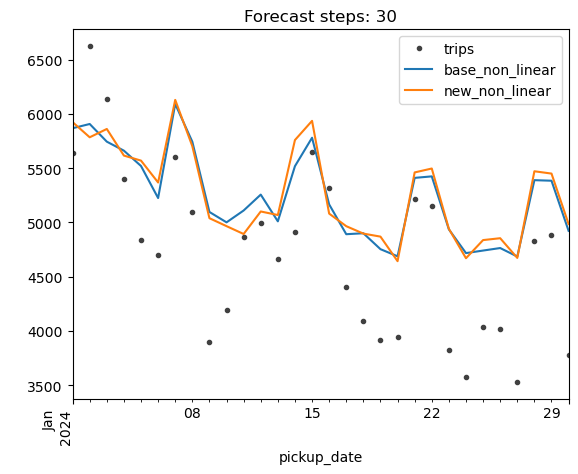

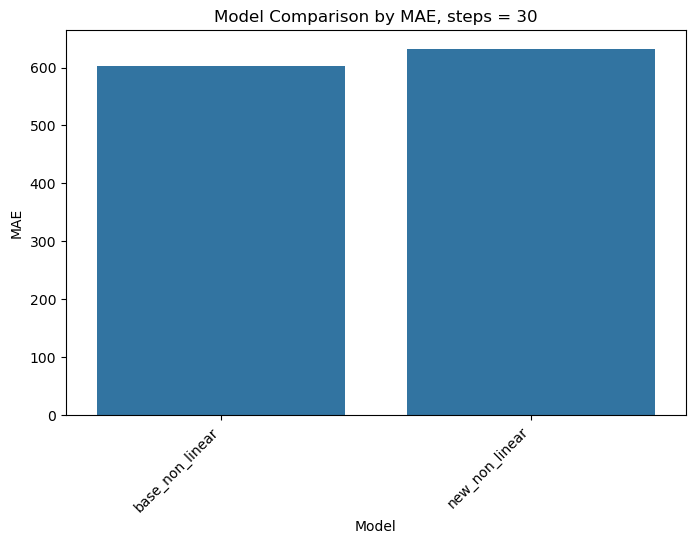

MAE Non Linear: 700.03 for step = 60, model = base_non_linear
MAE Non Linear: 650.87 for step = 60, model = new_non_linear


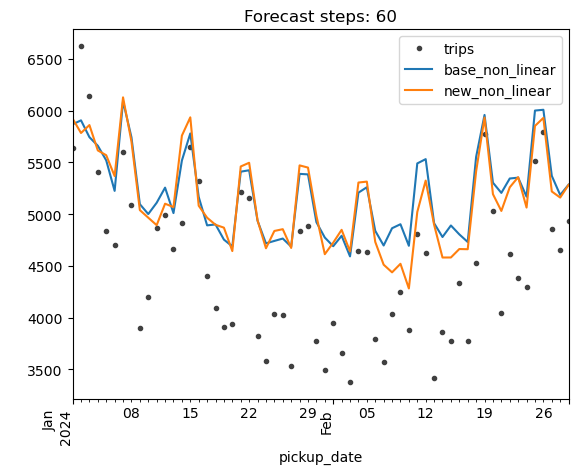

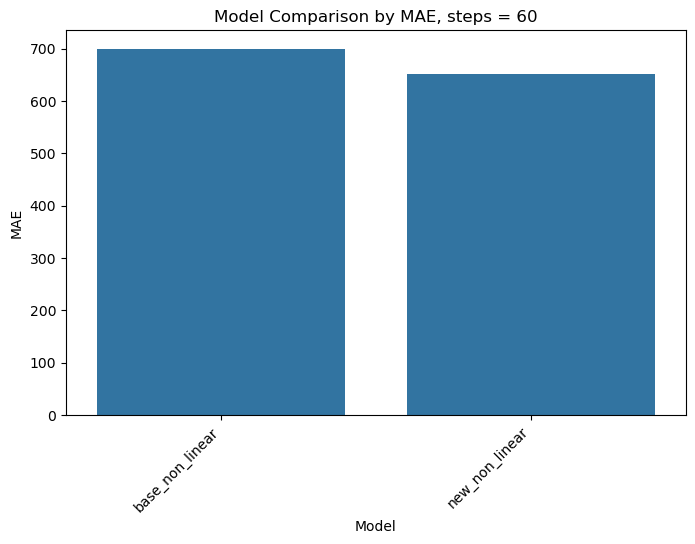

MAE Non Linear: 600.02 for step = 180, model = base_non_linear
MAE Non Linear: 561.84 for step = 180, model = new_non_linear


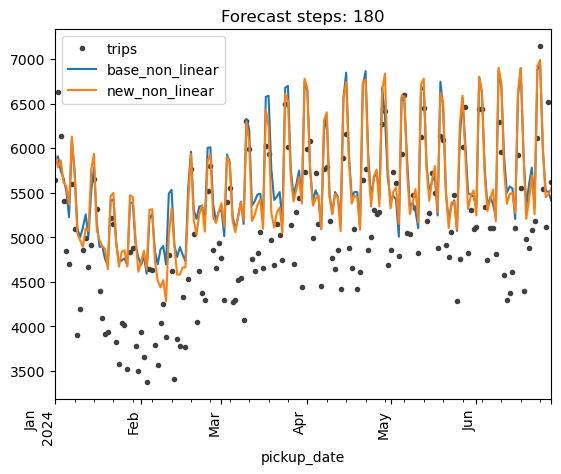

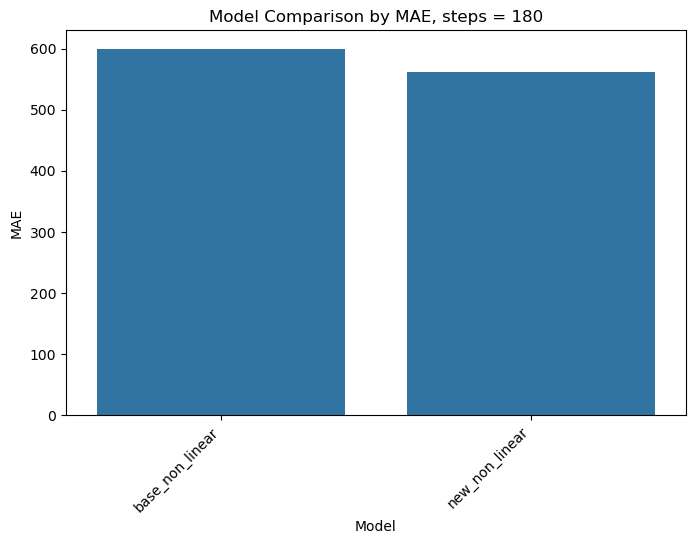

MAE Non Linear: 566.02 for step = 365, model = base_non_linear
MAE Non Linear: 550.65 for step = 365, model = new_non_linear


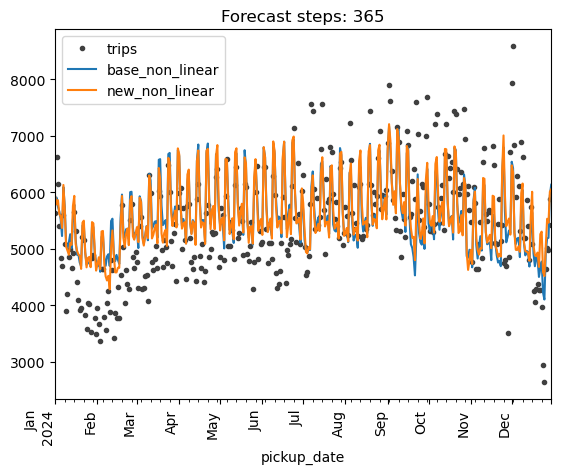

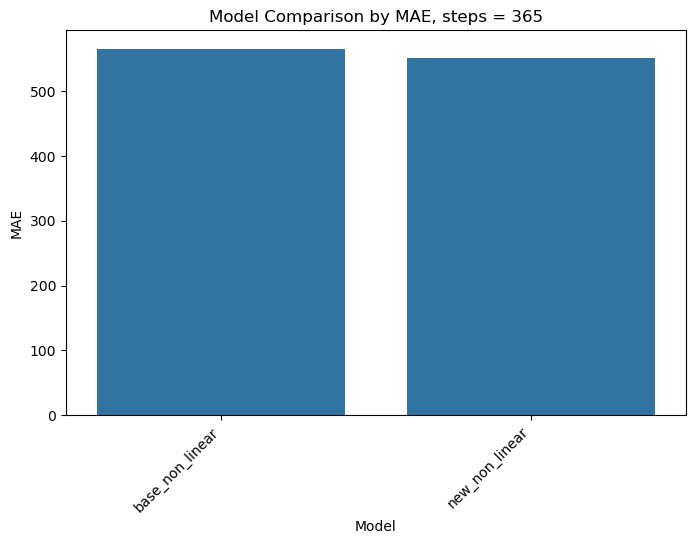

MAE Non Linear: 568.43 for step = 500, model = base_non_linear
MAE Non Linear: 553.21 for step = 500, model = new_non_linear


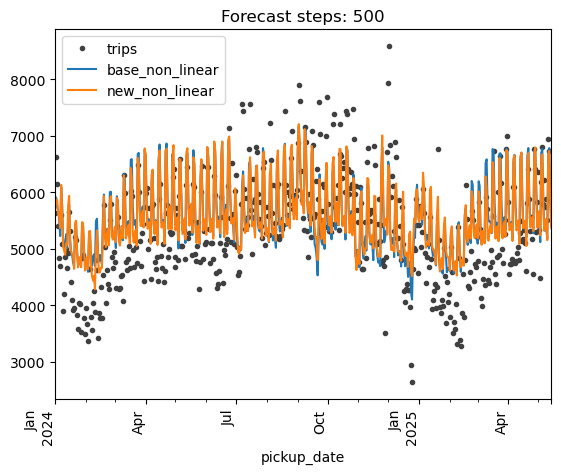

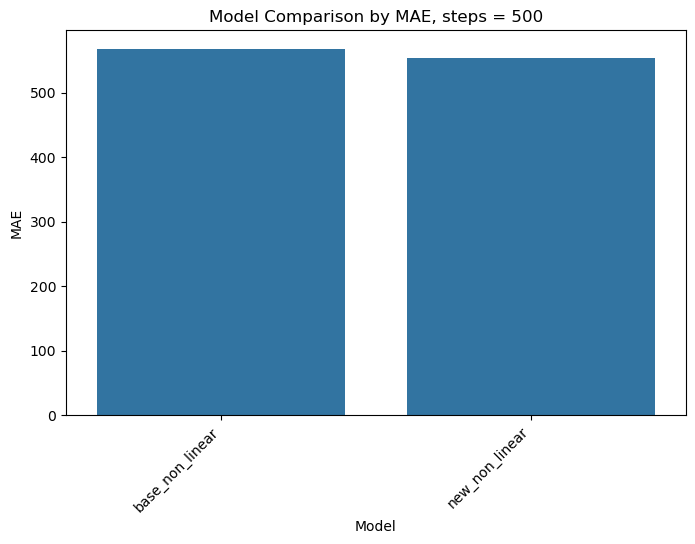

MAE Non Linear: 572.55 for step = 546, model = base_non_linear
MAE Non Linear: 559.40 for step = 546, model = new_non_linear


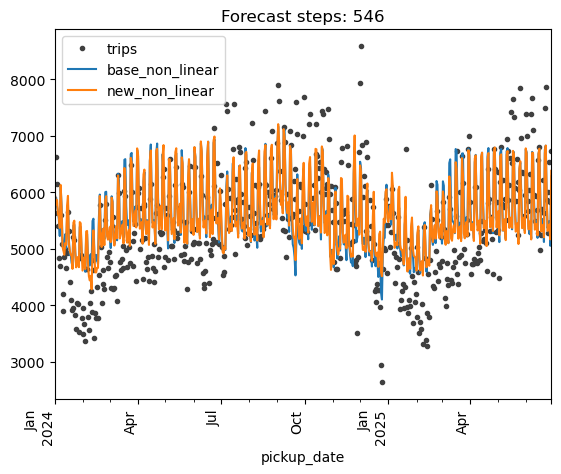

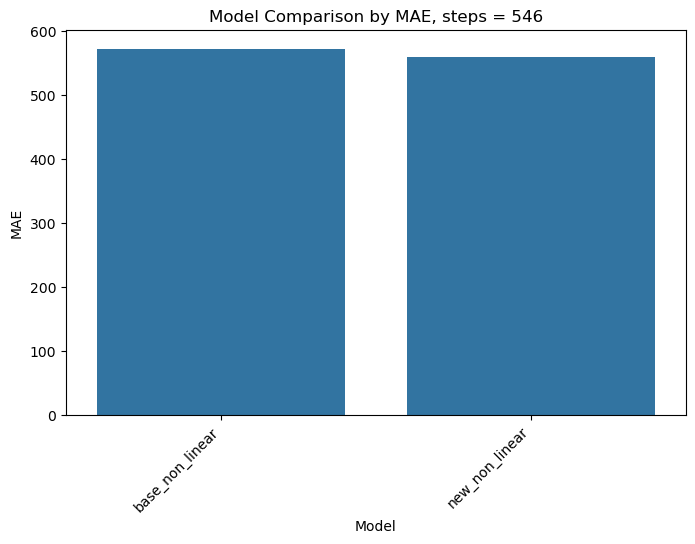

0

In [ ]:
# Run forecasts
run_forecasts(steps, daily_lags, {}, non_linear_models_loaded, False, "D", ts_daily_train, ts_daily_test)